# Exercise 2 — Industrial transfer learning with MVTec Capsule — Solution

In [10]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

repo_root = Path.cwd().parents[1] if Path.cwd().name == "solutions" else (Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
sys.path.append(str(repo_root / "src"))

from cvis_ml.config import DatasetConfig, ModelConfig, TrainConfig
from cvis_ml.data import MVTecCapsuleDataModule, make_class_weights_from_counts, auto_pin_memory
from cvis_ml.models import TransferModelFactory, count_parameters, describe_trainable_parameters
from cvis_ml.engine import run_transfer_experiment, resolve_device
from cvis_ml.visualization import show_batch, plot_history, show_confusion_matrix, show_misclassified, results_table

torch.manual_seed(42)
np.random.seed(42)
device = resolve_device("auto")
print("Device:", device)
print("DataLoader pin_memory will be:", auto_pin_memory())

Device: cpu
DataLoader pin_memory will be: False


Classes: ['normal', 'abnormal']
Train counts: {0: 166, 1: 74}
Validation counts: {0: 68, 1: 31}


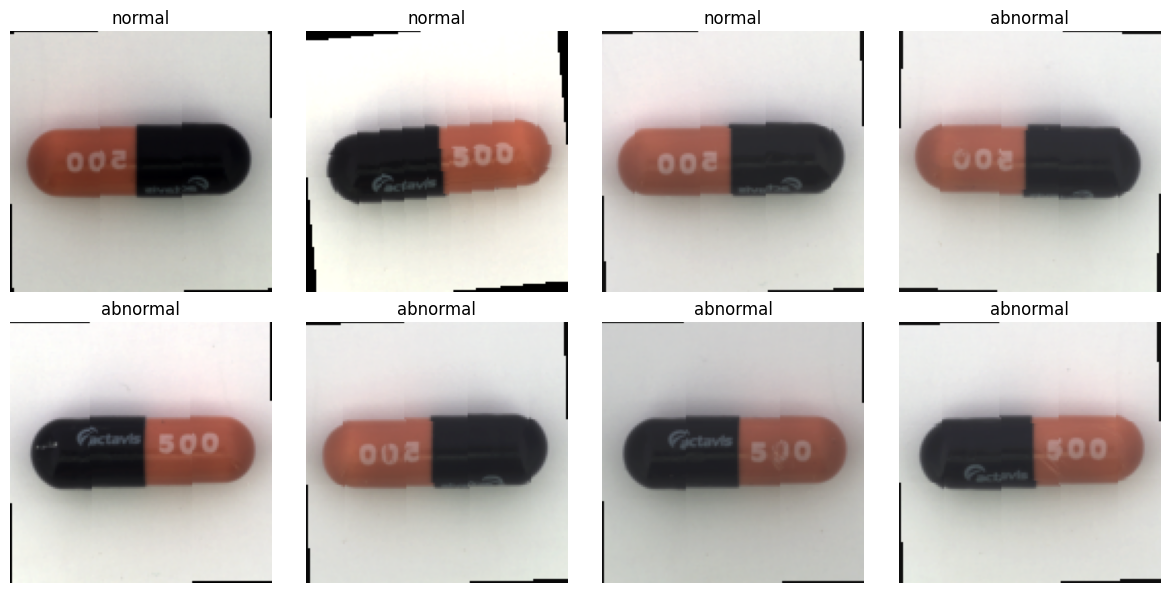

In [11]:
mvtec_cfg = DatasetConfig(
    name="mvtec_capsule_teaching_split",
    data_root=str(repo_root / "data_cache"),
    image_size=128,
    batch_size=16,
    max_train_samples=240,
    max_val_samples=120,
    num_workers=0,
    seed=42,
    augment=True,
)

mvtec_dm = MVTecCapsuleDataModule(
    root=mvtec_cfg.data_root,
    image_size=mvtec_cfg.image_size,
    batch_size=mvtec_cfg.batch_size,
    num_workers=mvtec_cfg.num_workers,
    max_train_samples=mvtec_cfg.max_train_samples,
    max_val_samples=mvtec_cfg.max_val_samples,
    seed=mvtec_cfg.seed,
    augment=mvtec_cfg.augment,
)
mvtec_data = mvtec_dm.setup()
print("Classes:", mvtec_data.class_names)
print("Train counts:", mvtec_data.train_counts)
print("Validation counts:", mvtec_data.val_counts)
show_batch(mvtec_data.train_loader, mvtec_data.class_names, n=8)

In [12]:
answer_A1 = """
The class counts should be inspected before interpreting metrics because accuracy can be misleading when the data are imbalanced.
The supervised teaching split is easier than the official anomaly-detection setup because both normal and abnormal examples are used for training.
However, validation results are still limited by small sample size, possible split bias, and the fact that this is not the official MVTec protocol.
"""
print(answer_A1)


The class counts should be inspected before interpreting metrics because accuracy can be misleading when the data are imbalanced.
The supervised teaching split is easier than the official anomaly-detection setup because both normal and abnormal examples are used for training.
However, validation results are still limited by small sample size, possible split bias, and the fact that this is not the official MVTec protocol.



In [13]:
architecture = "resnet18"
strategy = "frozen"

model_cfg = ModelConfig(
    architecture=architecture,
    strategy=strategy,
    pretrained=True,
    num_classes=mvtec_data.num_classes,
)
industrial_model = TransferModelFactory.create(
    architecture=model_cfg.architecture,
    strategy=model_cfg.strategy,
    pretrained=model_cfg.pretrained,
    num_classes=model_cfg.num_classes,
)
total_params, trainable_params = count_parameters(industrial_model)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
pd.DataFrame(describe_trainable_parameters(industrial_model, max_rows=20))

Total parameters: 11177538
Trainable parameters: 1026


,name,shape,numel
0,fc.weight,"(2, 512)",1024
1,fc.bias,"(2,)",2


Training on device: cpu


train:   0%|          | 0/15 [00:00<?, ?it/s]

eval:   0%|          | 0/7 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.7110425055027008, 'train_acc': 0.6083333333333333, 'val_loss': 0.6299961975642613, 'val_acc': 0.696969696969697, 'val_macro_f1': 0.5467032967032968}


train:   0%|          | 0/15 [00:00<?, ?it/s]

...

{'epoch': 9, 'train_loss': 0.6380020280679067, 'train_acc': 0.65, 'val_loss': 0.6162009366921016, 'val_acc': 0.696969696969697, 'val_macro_f1': 0.44088855421686746}


train:   0%|          | 0/15 [00:00<?, ?it/s]

eval:   0%|          | 0/7 [00:00<?, ?it/s]

{'epoch': 10, 'train_loss': 0.583248903354009, 'train_acc': 0.7041666666666667, 'val_loss': 0.5588963542665754, 'val_acc': 0.7373737373737373, 'val_macro_f1': 0.5927215189873418}


eval:   0%|          | 0/7 [00:00<?, ?it/s]

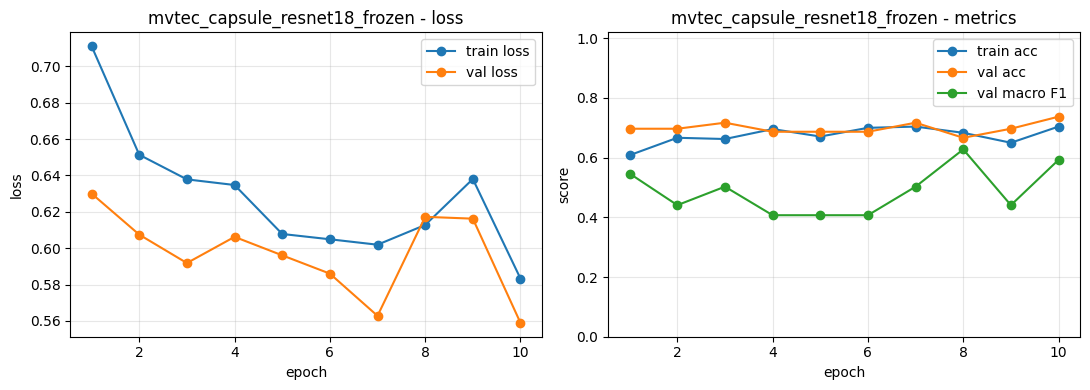

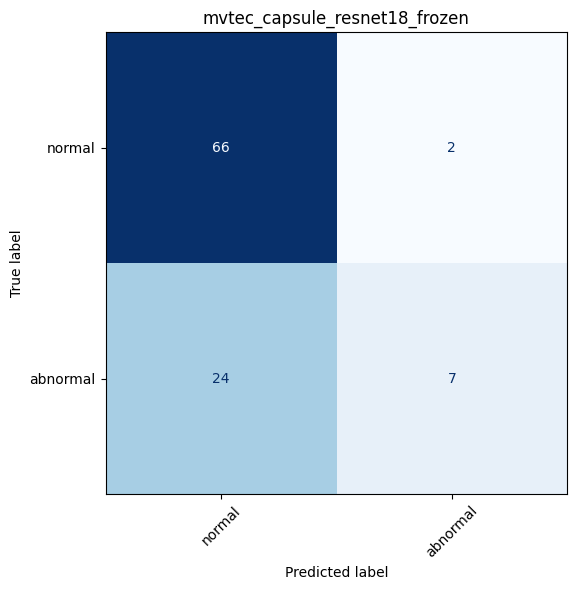

In [14]:
use_class_weights = False
class_weights = None
if use_class_weights:
    class_weights = make_class_weights_from_counts(mvtec_data.train_counts, num_classes=mvtec_data.num_classes)

train_cfg = TrainConfig(
    epochs=10,
    learning_rate=1e-3,
    weight_decay=1e-4,
    device="auto",
    use_class_weights=use_class_weights,
    max_batches_per_epoch=None,
    scheduler=None,
)

industrial_result = run_transfer_experiment(
    name=f"mvtec_capsule_{architecture}_{strategy}",
    model=industrial_model,
    train_loader=mvtec_data.train_loader,
    val_loader=mvtec_data.val_loader,
    epochs=train_cfg.epochs,
    learning_rate=train_cfg.learning_rate,
    weight_decay=train_cfg.weight_decay,
    device=train_cfg.device,
    class_weights=class_weights,
    max_batches_per_epoch=train_cfg.max_batches_per_epoch,
    scheduler=train_cfg.scheduler,
)
plot_history(industrial_result.history, title=industrial_result.name)
show_confusion_matrix(industrial_result.y_true, industrial_result.y_pred, mvtec_data.class_names, title=industrial_result.name)

In [15]:
answer_C = """
Validation accuracy and macro-F1 should be inspected together because this is a binary industrial task.
False normal errors are usually more critical because a defective product could be accepted.
False abnormal errors are also costly because they create unnecessary alarms or rework.
Even if the validation score is good, this would not yet be deployable because the dataset is small and the split is a teaching split, not a validation study.
"""
print(answer_C)


Validation accuracy and macro-F1 should be inspected together because this is a binary industrial task.
False normal errors are usually more critical because a defective product could be accepted.
False abnormal errors are also costly because they create unnecessary alarms or rework.
Even if the validation score is good, this would not yet be deployable because the dataset is small and the split is a teaching split, not a validation study.



In [17]:
def run_mvtec_setting(
    name,
    architecture,
    strategy,
    epochs,
    learning_rate,
    augment=True,
    use_class_weights=False,
    image_size=128,
    max_train_samples=240,
    max_val_samples=120,
):
    dm = MVTecCapsuleDataModule(
        root=mvtec_cfg.data_root,
        image_size=image_size,
        batch_size=mvtec_cfg.batch_size,
        num_workers=mvtec_cfg.num_workers,
        max_train_samples=max_train_samples,
        max_val_samples=max_val_samples,
        seed=mvtec_cfg.seed,
        augment=augment,
    )
    data = dm.setup()
    model_x = TransferModelFactory.create(
        architecture=architecture,
        strategy=strategy,
        pretrained=True,
        num_classes=data.num_classes,
    )
    weights = None
    if use_class_weights:
        weights = make_class_weights_from_counts(data.train_counts, num_classes=data.num_classes)

    result = run_transfer_experiment(
        name=name,
        model=model_x,
        train_loader=data.train_loader,
        val_loader=data.val_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        weight_decay=1e-4,
        device="auto",
        class_weights=weights,
        max_batches_per_epoch=None,
    )
    return result

mvtec_experiment_settings = [
    {"name": "mvtec_resnet18_frozen_ep8", "architecture": "resnet18", "strategy": "frozen", "epochs": 20, "learning_rate": 1e-3, "augment": True, "use_class_weights": False},
    {"name": "mvtec_resnet18_partial_ep5", "architecture": "resnet18", "strategy": "partial", "epochs": 20, "learning_rate": 1e-4, "augment": True, "use_class_weights": False},
    {"name": "mvtec_mobilenet_frozen_ep5", "architecture": "mobilenet_v3_small", "strategy": "frozen", "epochs": 20, "learning_rate": 1e-3, "augment": True, "use_class_weights": False},
]

industrial_results = [industrial_result]
for cfg in mvtec_experiment_settings:
    print("\nRunning", cfg)
    industrial_results.append(run_mvtec_setting(**cfg))
results_table(industrial_results)


Running {'name': 'mvtec_resnet18_frozen_ep8', 'architecture': 'resnet18', 'strategy': 'frozen', 'epochs': 20, 'learning_rate': 0.001, 'augment': True, 'use_class_weights': False}
Training on device: cpu


train:   0%|          | 0/15 [00:00<?, ?it/s]

eval:   0%|          | 0/7 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.6804131388664245, 'train_acc': 0.6208333333333333, 'val_loss': 0.8037116783005851, 'val_acc': 0.6868686868686869, 'val_macro_f1': 0.40718562874251496}


train:   0%|          | 0/15 [00:00<?, ?it/s]

...

train:   0%|          | 0/15 [00:00<?, ?it/s]

eval:   0%|          | 0/7 [00:00<?, ?it/s]

{'epoch': 20, 'train_loss': 0.5742852687835693, 'train_acc': 0.7208333333333333, 'val_loss': 0.5091398017747062, 'val_acc': 0.7272727272727273, 'val_macro_f1': 0.5847444461705764}


eval:   0%|          | 0/7 [00:00<?, ?it/s]

,name,val_acc,val_macro_f1,val_loss,runtime_s
2,mvtec_resnet18_partial_ep5,0.818182,0.765279,0.325591,270.596237
0,mvtec_capsule_resnet18_frozen,0.737374,0.592722,0.558896,128.492495
3,mvtec_mobilenet_frozen_ep5,0.727273,0.584744,0.509140,242.885559
1,mvtec_resnet18_frozen_ep8,0.717172,0.502869,0.575210,259.643745


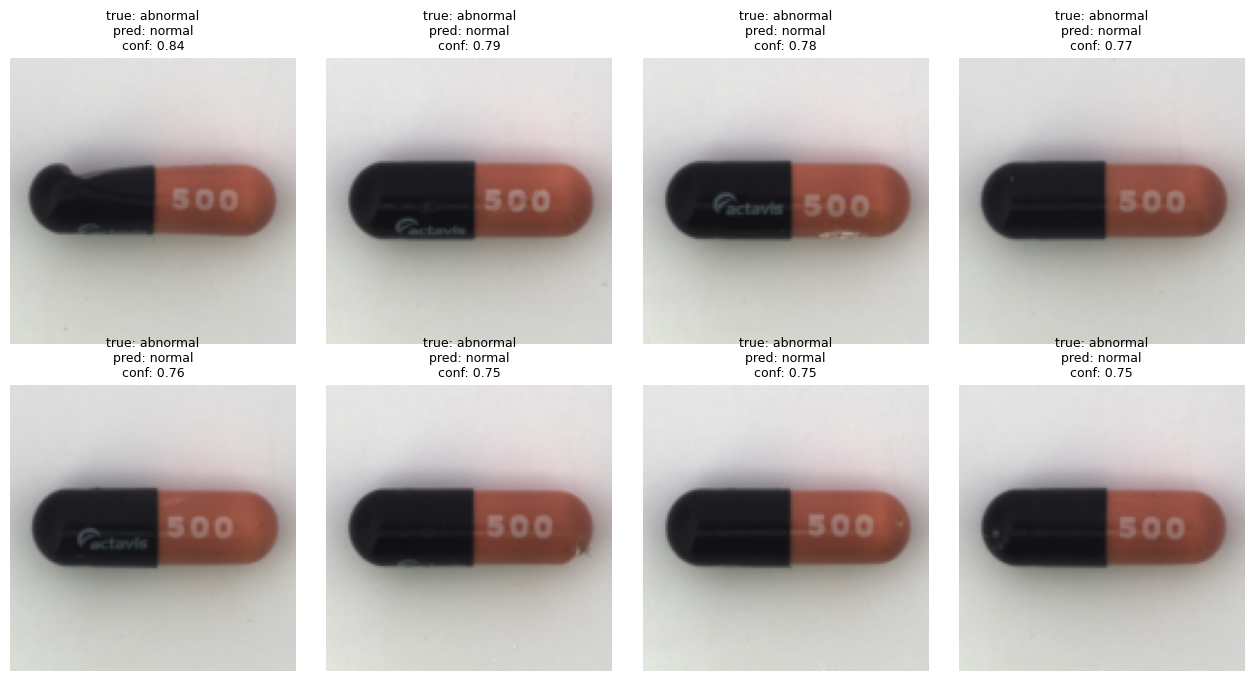

In [18]:
show_misclassified(
    industrial_model,
    mvtec_data.val_loader,
    mvtec_data.class_names,
    device=resolve_device("auto"),
    n=8,
    max_batches=20,
)

In [19]:
final_industrial_report = """
1. Best-performing setting:
This depends on runtime and random variation, but frozen ResNet18 is a strong baseline and partial fine-tuning can improve performance if the learning rate is small enough.

2. Most important hyperparameter effect:
Learning rate and number of epochs strongly affect stability. One epoch is not enough to judge transfer learning.

3. Preprocessing / augmentation effect:
Mild augmentation may improve robustness, but industrial augmentations must be physically plausible.

4. Industrial error analysis:
False abnormal means unnecessary alarm or rework.
False normal means a missed defect or quality escape, usually the more critical error.

5. What I would do before deployment:
Use a larger and more representative validation set, inspect failure modes, define acceptance criteria, test domain shift, calibrate thresholds, and compare against the official anomaly-detection protocol.

6. Documentation page I looked up and what I learned:
For example, TorchVision transforms or PyTorch AdamW; the key point is to understand the exact meaning of preprocessing and optimizer parameters.
"""
print(final_industrial_report)


1. Best-performing setting:
This depends on runtime and random variation, but frozen ResNet18 is a strong baseline and partial fine-tuning can improve performance if the learning rate is small enough.

2. Most important hyperparameter effect:
Learning rate and number of epochs strongly affect stability. One epoch is not enough to judge transfer learning.

3. Preprocessing / augmentation effect:
Mild augmentation may improve robustness, but industrial augmentations must be physically plausible.

4. Industrial error analysis:
False abnormal means unnecessary alarm or rework.
False normal means a missed defect or quality escape, usually the more critical error.

5. What I would do before deployment:
Use a larger and more representative validation set, inspect failure modes, define acceptance criteria, test domain shift, calibrate thresholds, and compare against the official anomaly-detection protocol.

6. Documentation page I looked up and what I learned:
For example, TorchVision transfo